# Crear blueprint

### Imports

In [26]:
import itertools
import pickle
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import os
import time
from numba import jit, njit
from numba.types import bool_, int_, float32
from math import comb
from copy import deepcopy
from tqdm import tqdm
import networkx as nx
import pandas as pd
from collections import defaultdict
from itertools import permutations
from pathlib import Path

### Llegir fulls de càlcul 

In [11]:
from pathlib import Path
import os

print("Working directory:", Path.cwd())
print("datasets.ods aquí:", Path("datasets.ods").exists())
print("datasets.ods un nivell enrere:", Path("../datasets.ods").exists())

Working directory: c:\Users\UX433\OneDrive\Escritorio\pràctiques\networkalignment\notebooks
datasets.ods aquí: False
datasets.ods un nivell enrere: True


In [12]:
from pathlib import Path

### Obrim els fitxers
fulls = 8
# n_grupo = 4 - ara no estic fent servir grups

# El notebook pot executar-se des de la carpeta arrel o des de notebooks/,
# així que provem les dues rutes possibles.
possible_paths = [
    Path("datasets.ods"),
    Path("../datasets.ods"),
    Path("data/datasets.ods"),
    Path("../data/datasets.ods"),
]

dataset_path = None

for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError(
        "No s'ha trobat datasets.ods. Comprova que el fitxer estigui a la carpeta arrel "
        "del repo o dins de data/."
    )

print("Llegint dades des de:", dataset_path)

d = {}  # diccionari per emmagatzemar DataFrames
D = "Dataset"  # prefix dels fulls: Dataset1, Dataset2, ...

for i in range(fulls):
    sheet_name = D + str(i + 1)
    d["group" + str(i)] = pd.read_excel(dataset_path, sheet_name=sheet_name)
    # print("Read:", i, "size", d["group" + str(i)].shape)

Llegint dades des de: ..\datasets.ods


### Passar a matriu i binaritzem

Abans de construir les matrius d’adjacència, cal tenir en compte alguns detalls del format original dels fulls de càlcul.

En primer lloc, s’eliminen les tres primeres files i columnes de cada full, ja que no corresponen a dades de connectivitat, sinó a etiquetes i informació auxiliar del fitxer original.

En segon lloc, després d’aquest filtratge, les matrius obtingudes no són quadrades: tenen 227 files i 183 columnes. Com que una matriu d’adjacència ha de ser quadrada, es construeix una nova matriu de mida `nre_files × nre_files`, inicialitzada amb zeros. A continuació, es copien les columnes existents de la matriu original i es deixen a zero les columnes restants.

Aquesta decisió permet obtenir una matriu quadrada compatible amb els càlculs posteriors, però també pot introduir una limitació: els nodes associats a les columnes inexistents queden representats com si no tinguessin connexions sortints. Per tant, aquest punt s’ha de tenir en compte a l’hora d’interpretar els resultats.

**Nota:** en els datasets originals, la primera columna s’utilitza com a columna de títols o identificadors, no com a dades de connectivitat.


In [13]:
## Hipermatriu M amb les dades dels fulls de càlcul
## Ens quedem només amb la part de sinapsis, sense les etiquetes inicials

rows = d["group" + str(i)].shape[0] - 3
columns = d["group" + str(i)].shape[1] - 3  # les 3 primeres files i columnes no contenen dades de connexió

M = np.zeros((fulls, rows, columns))

for i in range(0, fulls):
    Data = d["group" + str(i)]
    M[i, :, :] = Data.iloc[3:, 3:]  # copiem només el bloc numèric de connexions


## Com que treballem amb matrius d'adjacència, volem matrius quadrades
## Si falten columnes, les deixem a zero, interpretant que no hi ha connexions en aquelles posicions

M_square = np.zeros((fulls, rows, rows))  # creo una matriu quadrada per a cada full
M_square[:, :, 0:columns] = M[:, :, :]   # copio les columnes existents i deixo la resta plena de zeros


## Binarització de les matrius
## Ignorem el pes de les connexions: si hi ha almenys una sinapsi, posem 1; si no, posem 0

M_square_bin = np.zeros((fulls, rows, rows))

for i in range(fulls):
    for j in range(rows):
        for k in range(columns):
            if M[i, j, k] >= 1:
                M_square_bin[i, j, k] = 1


Nx = rows  # nombre de nodes; hem forçat que les matrius siguin quadrades de mida rows x rows


### Comprovació de l’estructura dels fulls de càlcul

Vull assegurar-me de que la neteja dels Datasets (primeres 3 files i columnes) està feta correctament. Nota: Els Datasets prenen la primera fila com un Títol  ('Pre', en aquest cas). Per tant, realment n'estic esborrant 4.

In [14]:
# inspecció ràpida d'un full de càlcul (group 7-->Dataset8)
df7 = d['group7']
print("Shape original group7:", df7.shape)
print("\nColumn names (first 12):\n", df7.columns[:12])
print("\nPrimeres 8 files i 8 columnes (sense transformar):")
print(df7.iloc[:8, :8])

Shape original group7: (227, 183)

Column names (first 12):
 Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Pre', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

Primeres 8 files i 8 columnes (sense transformar):
  Unnamed: 0 Unnamed: 1 Unnamed: 2      Pre Unnamed: 4 Unnamed: 5 Unnamed: 6  \
0        NaN        NaN        NaN  Sensory        NaN        NaN        NaN   
1        NaN        NaN        NaN     ADFL       ADFR       ADLL       ADLR   
2        NaN        NaN        NaN      NaN        NaN        NaN        NaN   
3       Post    Sensory       ADFL        0          0          0          0   
4        NaN        NaN       ADFR        0          0          0          0   
5        NaN        NaN       ADLL        0          0          0          0   
6        NaN        NaN       ADLR        0          0          0          0   
7        NaN        NaN       AFDL      

## Escollir quin és el dataset A2

Sabem (per la informació del paper) que A2 té aproximadament 2186 arestes (edges), comprovem si el Dataset8 concorda amb aquestes dades, mirem cada dataset (recordem que group0-->Dataset1, group1-->Dataset2, ...).

NOTA: A més sospitem que el Dataset8 és el que conté les dades de A2 perquè al repo de la Teresa es pren A2 com a Blueprint fent M_square_bin[-1] que correspon a l'últim element de l'array, és a dir, M_square_bin[7], que correspon a group7--> Dataset8

### Coprovació de que Dataset8 correspon a A2

In [15]:
# Veure quants edges té cada dataset
for i in range(8):
    print(i, M_square_bin[i].sum())

0 775.0
1 986.0
2 1012.0
3 1136.0
4 1515.0
5 1525.0
6 2202.0
7 2186.0


## Guardar A2 com blueprint

Volem crear i guardar el blueprint A2 (Dataset8 = group7 = M_square_bin[-1])


In [16]:
#Seleccionem A2, és a dir, el dataset8
A2=M_square_bin[-1].copy()
#Fem comprovacions
print("A2 creat")
print("Files i columnes A2", A2.shape)
print("Arestes", int(A2.sum()))
#guardem
np.save("A2_blueprint.npy", A2)
print("Guardat com A2_blueprint")

A2 creat
Files i columnes A2 (224, 224)
Arestes 2186
Guardat com A2_blueprint


# Generar xarxes amb p i q



En aquesta secció faig una primera implementació del mecanisme generatiu del model probabilístic. La idea és partir de la matriu `A2_blueprint.npy` i generar diverses còpies sorolloses.

Segons el model, si en el blueprint hi ha un enllaç ((L_{ij}=1)), aquest es conserva amb probabilitat (1-q) i s’esborra amb probabilitat (q). En canvi, si en el blueprint no hi ha cap enllaç ((L_{ij}=0)), es manté com a no-enllaç amb probabilitat (1-p) i apareix un fals positiu amb probabilitat (p).

Això encara no és el procés complet d’inferència ni de sampling del posterior. És només una comprovació inicial del model directe: generar xarxes observades a partir d’un blueprint conegut.


In [17]:
# Variables d'interès
L = np.load("A2_blueprint.npy").astype(int)

q_paper = 0.15   # probabilitat d'esborrar un enllaç existent
p_paper = 0.007  # probabilitat d'afegir un fals enllaç on no n'hi havia

num_networks = 2


def CreateCopies(L, q, p, num_networks, seed=None):
    """
    Genera còpies sorolloses d'una xarxa blueprint L.

    q: probabilitat d'esborrar un enllaç existent.
    p: probabilitat d'afegir un enllaç fals en una posició buida.
    """

    if seed is not None:
        np.random.seed(seed)

    Nx = len(L)  # nombre de nodes
    A_test = np.zeros((num_networks, Nx, Nx), dtype=int)  # array 3D per guardar les xarxes generades

    for k in range(num_networks):
        for i in range(Nx):
            for j in range(Nx):

                if i == j:
                    # Evitem autoenllaços a la diagonal
                    A_test[k, i, j] = 0

                elif L[i, j] == 1:
                    # Si l'enllaç existeix al blueprint, es conserva amb probabilitat 1-q
                    if np.random.rand() >= q:
                        A_test[k, i, j] = 1

                else:
                    # Si no hi ha enllaç al blueprint, pot aparèixer un fals positiu amb probabilitat p
                    if np.random.rand() < p:
                        A_test[k, i, j] = 1

    return A_test


# Generem les xarxes sintètiques utilitzant els valors de p i q del paper
A_test = CreateCopies(
    L=L,
    q=q_paper,
    p=p_paper,
    num_networks=num_networks,
    seed=11
)

print("Xarxes generades amb p i q del paper:")
print("Shape:", A_test.shape)

for k in range(num_networks):
    print(f"Xarxa {k + 1}:")
    print("  Nombre d'enllaços:", int(A_test[k].sum()))
    print("  Diferències respecte el blueprint:", int(np.abs(A_test[k] - L).sum()))

np.save("synthetic_paper.npy", A_test)
print("Fitxer guardat com synthetic_paper.npy")

Xarxes generades amb p i q del paper:
Shape: (2, 224, 224)
Xarxa 1:
  Nombre d'enllaços: 2178
  Diferències respecte el blueprint: 710
Xarxa 2:
  Nombre d'enllaços: 2217
  Diferències respecte el blueprint: 711
Fitxer guardat com synthetic_paper.npy


In [18]:
# Fem diverses repeticions per veure si la generació de xarxes és coherent.
# Fixem una llavor una sola vegada perquè els resultats siguin reproduïbles,
# però cada repetició genera xarxes diferents.

np.random.seed(11)

for nrep in range(10):
    A_test = CreateCopies(L, q_paper, p_paper, num_networks=2)

    for k in range(num_networks):
        # Diferències totals respecte el blueprint
        total_differences = int(np.abs(A_test[k] - L).sum())

        # Enllaços que existien a L però s'han esborrat a la còpia
        deleted_edges = int(((L == 1) & (A_test[k] == 0)).sum())

        # Enllaços falsos que no existien a L però apareixen a la còpia
        false_edges = int(((L == 0) & (A_test[k] == 1)).sum())

        print(
            f"rep {nrep}, xarxa {k + 1}: "
            f"diferències totals = {total_differences}, "
            f"enllaços esborrats = {deleted_edges}, "
            f"falsos enllaços = {false_edges}"
        )

rep 0, xarxa 1: diferències totals = 710, enllaços esborrats = 359, falsos enllaços = 351
rep 0, xarxa 2: diferències totals = 711, enllaços esborrats = 340, falsos enllaços = 371
rep 1, xarxa 1: diferències totals = 640, enllaços esborrats = 323, falsos enllaços = 317
rep 1, xarxa 2: diferències totals = 664, enllaços esborrats = 312, falsos enllaços = 352
rep 2, xarxa 1: diferències totals = 660, enllaços esborrats = 323, falsos enllaços = 337
rep 2, xarxa 2: diferències totals = 626, enllaços esborrats = 299, falsos enllaços = 327
rep 3, xarxa 1: diferències totals = 709, enllaços esborrats = 330, falsos enllaços = 379
rep 3, xarxa 2: diferències totals = 683, enllaços esborrats = 329, falsos enllaços = 354
rep 4, xarxa 1: diferències totals = 648, enllaços esborrats = 309, falsos enllaços = 339
rep 4, xarxa 2: diferències totals = 689, enllaços esborrats = 333, falsos enllaços = 356
rep 5, xarxa 1: diferències totals = 656, enllaços esborrats = 328, falsos enllaços = 328
rep 5, xar

Si ho vull fer tal com em va dir la marta, emplenant una matriu feta de 0s seria aixi.

In [19]:
# Comprovació del nombre d'enllaços i dels errors introduïts

original_edges = int(L.sum())

# Com que no considerem autoenllaços, el nombre total de posicions possibles és Nx*(Nx-1)
possible_edges = Nx * (Nx - 1)
zeros_original = possible_edges - original_edges

print("Blueprint A2")
print("  Nombre d'enllaços:", original_edges)
print("  Nombre de no-enllaços:", zeros_original)

print("\nValors esperats aproximats segons p i q:")
print("  Enllaços esborrats esperats:", round(q_paper * original_edges, 2))
print("  Falsos enllaços esperats:", round(p_paper * zeros_original, 2))

for k in range(num_networks):
    edges_new = int(A_test[k].sum())

    # Enllaços que existien al blueprint i han desaparegut a la còpia
    deleted_edges = int(((L == 1) & (A_test[k] == 0)).sum())

    # Enllaços que no existien al blueprint però apareixen a la còpia
    false_edges = int(((L == 0) & (A_test[k] == 1)).sum())

    total_differences = deleted_edges + false_edges

    print(f"\nXarxa {k + 1}")
    print("  Nombre d'enllaços:", edges_new)
    print("  Enllaços esborrats:", deleted_edges)
    print("  Falsos enllaços:", false_edges)
    print("  Diferències totals respecte el blueprint:", total_differences)


Blueprint A2
  Nombre d'enllaços: 2186
  Nombre de no-enllaços: 47766

Valors esperats aproximats segons p i q:
  Enllaços esborrats esperats: 327.9
  Falsos enllaços esperats: 334.36

Xarxa 1
  Nombre d'enllaços: 2177
  Enllaços esborrats: 343
  Falsos enllaços: 334
  Diferències totals respecte el blueprint: 677

Xarxa 2
  Nombre d'enllaços: 2216
  Enllaços esborrats: 313
  Falsos enllaços: 343
  Diferències totals respecte el blueprint: 656


## Funcions d'energia

Les funcions següents són una adaptació directa de les funcions utilitzades al repositori associat al paper. En aquest notebook no es modifiquen substancialment, sinó que s’utilitzen com a eina per comprovar si l’alineament correcte té una energia més baixa que alineaments aleatoris.

No considerem grups, per tant:

In [20]:
n_groups = 1 #considerem que els nodes pertanyen a un únic grup
start_groups = np.zeros(1) #indica on comença cada grup
end_groups = np.zeros(1) + Nx #indica on acaba
size_groups = np.zeros(1) + Nx

start_groups, end_groups, size_groups = start_groups.astype(int), end_groups.astype(int), size_groups.astype(int)

Aquestes son les funcions d'energia tal qual com estan al repo del paper

In [21]:
@jit(nopython = True)
def hamiltonian_prob(Edges_NoL, Edges_L, overlap_0, overlap_1, alpha, beta):

    A_1 = overlap_1 + alpha #o11 al paper
    B_1 = (Edges_L - overlap_1 + beta) #o10 al paper
    C_1 = Edges_L + alpha + beta #o1 al paper
    
    A_0 = overlap_0 + alpha #o00 al paper
    B_0 = (Edges_NoL - overlap_0 + beta) # o01 al paper
    C_0 = Edges_NoL + alpha + beta # o0 al paper
    
    #  [ math.lgamma(n+1) == log(n!) ]
    H1 = math.lgamma(A_1)+ math.lgamma(B_1) - math.lgamma(C_1) 
    H0 = math.lgamma(A_0)+ math.lgamma(B_0) - math.lgamma(C_0) 
    
    H = -(H1 + H0)
    return H
    
    
@jit(nopython=True)
def overlap_total_prob(L_f, A_f, P_inv_f):
    Nx = L_f.shape[0]
    Ny = L_f.shape[1]
    K = A_f.shape[0]
    
    ovlp_0 = np.zeros((K))
    ovlp_1 = np.zeros((K))
    for k in range(0,K):
        for f in range(0,Ny): 
            for c in range(0,Nx):
                p_f=int(P_inv_f[k,f]) #es tradueix l'index del bliueprint al real de 
                 #(per exemple, si el node 1 de L es el node 5 de A, p_f=5)
                p_c=int(P_inv_f[k,c])  
                valor_L, valor_A = L_f[f,c], A_f[k,p_f,p_c] #compara el valor de L i A a la posició corresponent
                
                ovlp_0[k] = ovlp_0[k] + (1-valor_L)*(1-valor_A )#mira si els zeros coincideixen a L i a A
                ovlp_1[k] = ovlp_1[k] + valor_L*valor_A #mira si els 1s coincideixen a 0 i a  A
                
                
    ovlp_1 = int(sum(ovlp_1))
    ovlp_0 = int(sum(ovlp_0)) #se sumen coincidencies en totes les observacions, resultat global
    return ovlp_0, ovlp_1
#retorna ovlp_0 (nre total de no-enllaços ben predits) i ovlp_1 (nre total d'enllacos ben predits)

@jit(nopython=True) # The blueprint is the average of the observations (taking into account the mapping)  
def L_wiring(A_f, P_inv_f): #enlaces que aparecen en la mayoría de observaciones
    #A_f:  te la forma KxNxNy, on K és el nre de xarxes observades
    Nx = A_f.shape[1]
    Ny = A_f.shape[2]
    K = A_f.shape[0] 
    L_new_f = np.zeros((Nx,Ny))
    
    for i in range(0,Nx):
        for j in range(0,Ny):
            for k in range(0,K):
                #per cada posicio (ij) mira en les K xarxes la posicio que li correspon al blueprint (equivalent segons el mapping)
                p1 = int(P_inv_f[k,i]) # Mapping of the observations
                p2 = int(P_inv_f[k,j]) # Mapping of the observations
                L_new_f[i,j] += A_f[k,p1,p2] #sumo les connexions existents a la posició equivalent en les K xarxes observades
            valor_lnew=1/K* L_new_f[i,j] #fa la mitjana de connexions existents en les K xarxes observades
            L_new_f[i,j] = round( valor_lnew ) #redondeja al valor més proper
            # If valor_lnew = 0, L=0 (we could establish L=1, but it is more probable to not have a connection)
            #L_ij=1--> a la majoria de les k observacions alineades hi ha enllaç aquí
            # L_ij=0--> a la majoria de les k observacions alineades no hi ha enllaç aquí 
    return L_new_f


#### Some algorithm for sorting
@jit(nopython=True)
def partition(array,  etiquetas, begin, end):
    pivot = begin
    for i in range(begin+1, end+1):
        if array[i] < array[begin]:
            pivot += 1
            array[i], array[pivot] = array[pivot], array[i]
            etiquetas[i], etiquetas[pivot] = etiquetas[pivot], etiquetas[i]
    array[pivot], array[begin] = array[begin], array[pivot]
    etiquetas[pivot], etiquetas[begin] = etiquetas[begin], etiquetas[pivot] 

    return pivot
@jit(nopython=True)
def quicksort(array, etiquetas, begin=0, end=None):
    if end is None:
        end = len(array) - 1
    if begin >= end: #To end
        return
    pivot = partition(array,  etiquetas, begin, end)
    
    #Order right and left
    quicksort(array, etiquetas, begin, pivot-1)
    quicksort(array,  etiquetas, pivot+1, end)
    
@njit 
# We inizialise the algorithm sorting by node degree, but also taking into account the group labels
def permu_groups(L_f, A_f, start_f): 
    Nx = L_f.shape[0]
    Ny = L_f.shape[1]
    K = A_f.shape[0]
    N_groups = len(start_f)
    
    
    # Mappings
    P_f = np.zeros((K,Nx)) #Mapping from L to A
    P_inv_f = np.zeros((K,Nx)) #Mapping from A to L
    P_new = np.zeros((K,Nx))
    
    # First we order the blueprint and after the observations
    # Blueprint:
    orden_L=np.zeros((Nx))
    for i in range(Nx):
        b=np.nonzero(L_f[i,:])
        orden_L[i] = b[0].size
        
    array_L = np.arange(Nx) #For the labels 
    quicksort(orden_L, array_L)
    
    # Now according to the group label
    array_L_labels = np.zeros((Nx))
    group_number = np.zeros((N_groups))
    for i in range(Nx):
        n_type = 0
        #Group
        while ( (array_L[i] >= start_f[n_type]) and (n_type < N_groups)):
            n_type += 1
       
        grupo = int(n_type-1)
        g = int(start_f[grupo])
        array_L_labels[g + int(group_number[grupo])] = array_L[i]
        group_number[grupo] += 1

    #Observations: 
    for i in range(0,K):
        orden_A = np.zeros((Nx))
        for i_orden in range(Nx):
            b = np.nonzero(A_f[i,i_orden,:])
            orden_A[i_orden] = b[0].size

        array_A = np.arange(Nx) #For the labels 
        quicksort(orden_A, array_A)
            
        # Now according to the group label
        array_A_labels = np.zeros((Nx))
        group_number = np.zeros((N_groups))
        
        for i_g in range(Nx):
            n_type = 0
            while ( (array_A[i_g] >= start_f[n_type]) and (n_type < N_groups) ):
                n_type += 1

            grupo = int(n_type-1)
            g = int(start_f[grupo])
            array_A_labels[ g + int(group_number[grupo])] = array_A[i_g]
            group_number[grupo] += 1
    

    # Now ordered together both label array  array_L = [0,1,2,3...]
        array_A_labels = array_A_labels[np.argsort(array_L_labels)]
        P_f[i,:] = array_A_labels
        
        for i_inv in range(0,Nx):
            for j_inv in range(0,Ny):
                if (P_f[i,i_inv] == j_inv):
                    P_inv_f[i, j_inv]=i_inv
    
    P_todo = np.zeros((2,K,Nx))
    P_todo[0,:,:] = P_f.copy() 
    P_todo[1,:,:] = P_inv_f.copy()

    return P_todo

 

## Generació de mostres i comparació d’energies

En aquesta secció faig una comprovació senzilla de les funcions d’energia. La idea és generar diverses parelles de xarxes sintètiques a partir de la mateixa blueprint i comparar dues situacions:

1. l’alineament identitat, on no es permuten els nodes;
2. alineaments aleatoris, obtinguts aplicant shuffles independents als nodes de cada xarxa.

Si el model d’energia està funcionant de manera raonable, l’alineament identitat hauria de donar energies més baixes que la majoria d’alineaments aleatoris. Aquesta prova no és encara un procés complet de MCMC, sinó un sanity check per veure si l’energia distingeix configuracions estructuralment coherents de configuracions aleatòries.


In [32]:
from pathlib import Path

# Paràmetres de la prova
num_samples = 10
n_shuffles = 500

# Fem servir els valors de referència del paper
q_test = q_paper
p_test = p_paper

alpha = 1.0
beta = 5.0

print("Paràmetres de la prova:")
print("q_test =", q_test)
print("p_test =", p_test)
print("num_samples =", num_samples)
print("n_shuffles per mostra =", n_shuffles)
print("alpha =", alpha)
print("beta =", beta)

Paràmetres de la prova:
q_test = 0.8
p_test = 0.03644092519274849
num_samples = 10
n_shuffles per mostra = 500
alpha = 1.0
beta = 5.0


In [33]:
def compute_energy_for_permutation(Ao_enters, P_inv, alpha=1.0, beta=5.0):
    """
    Calcula l'energia associada a una permutació concreta dels nodes.

    Ao_enters: xarxes observades/sintètiques.
    P_inv: permutacions inverses aplicades a cada xarxa.
    """

    # Construïm la blueprint associada a aquesta permutació
    L_current = L_wiring(Ao_enters, P_inv)

    # Calculem els solapaments entre la blueprint i les xarxes
    ovlp0, ovlp1 = overlap_total_prob(L_current, Ao_enters, P_inv)

    # Nombre d'entrades 1 i 0 de la blueprint, multiplicat pel nombre de xarxes
    Nx_local = L_current.shape[0]
    edges_L = Ao_enters.shape[0] * int(L_current.sum())
    edges_NoL = Ao_enters.shape[0] * Nx_local * Nx_local - edges_L

    # Energia probabilística
    H = hamiltonian_prob(
        edges_NoL,
        edges_L,
        ovlp0,
        ovlp1,
        alpha,
        beta
    )

    return float(H)

Apliquem shuffles per generar xarxes random

In [34]:
rng = np.random.default_rng(123)

H_identity_list = []
H_shuffle_all = []
H_shuffle_by_sample = []
summary_rows = []

for sample_id in range(num_samples):

    # Generem una parella de xarxes sintètiques
    A_sample = CreateCopies(
        L=L,
        q=q_test,
        p=p_test,
        num_networks=num_networks,
        seed=1000 + sample_id
    ).astype(int)

    Ao_enters = A_sample.astype(int)

    # Permutació identitat
    P_inv_id = np.tile(np.arange(Nx), (num_networks, 1)).astype(np.int64)

    H_identity = compute_energy_for_permutation(
        Ao_enters,
        P_inv_id,
        alpha=alpha,
        beta=beta
    )

    H_identity_list.append(H_identity)

    # Shuffles aleatoris
    H_shuffles_sample = []

    for t in range(n_shuffles):
        P_inv_shuffle = np.array(
            [rng.permutation(Nx) for _ in range(num_networks)],
            dtype=np.int64
        )

        H_shuffle = compute_energy_for_permutation(
            Ao_enters,
            P_inv_shuffle,
            alpha=alpha,
            beta=beta
        )

        H_shuffles_sample.append(H_shuffle)
        H_shuffle_all.append(H_shuffle)

    H_shuffles_sample = np.array(H_shuffles_sample)
    H_shuffle_by_sample.append(H_shuffles_sample)

    fraction_lower_than_identity = np.mean(H_shuffles_sample < H_identity)

    summary_rows.append({
        "sample": sample_id,
        "H_identity": H_identity,
        "mean_H_shuffle": H_shuffles_sample.mean(),
        "min_H_shuffle": H_shuffles_sample.min(),
        "max_H_shuffle": H_shuffles_sample.max(),
        "fraction_shuffles_lower_than_identity": fraction_lower_than_identity
    })

    print(
        f"Mostra {sample_id}: "
        f"H_identitat = {H_identity:.2f}, "
        f"mitjana shuffles = {H_shuffles_sample.mean():.2f}, "
        f"fracció shuffles millors = {fraction_lower_than_identity:.3f}"
    )

energy_summary = pd.DataFrame(summary_rows)
display(energy_summary)

Mostra 0: H_identitat = 16702.20, mitjana shuffles = 16952.22, fracció shuffles millors = 0.000
Mostra 1: H_identitat = 16929.69, mitjana shuffles = 17339.07, fracció shuffles millors = 0.000
Mostra 2: H_identitat = 16694.78, mitjana shuffles = 17079.86, fracció shuffles millors = 0.000
Mostra 3: H_identitat = 16942.26, mitjana shuffles = 17363.74, fracció shuffles millors = 0.000
Mostra 4: H_identitat = 17258.61, mitjana shuffles = 17566.44, fracció shuffles millors = 0.000
Mostra 5: H_identitat = 16824.26, mitjana shuffles = 17316.83, fracció shuffles millors = 0.000
Mostra 6: H_identitat = 17062.70, mitjana shuffles = 17443.51, fracció shuffles millors = 0.000
Mostra 7: H_identitat = 17151.47, mitjana shuffles = 17483.38, fracció shuffles millors = 0.000
Mostra 8: H_identitat = 16967.29, mitjana shuffles = 17417.17, fracció shuffles millors = 0.000
Mostra 9: H_identitat = 17223.60, mitjana shuffles = 17582.60, fracció shuffles millors = 0.000


,sample,H_identity,mean_H_shuffle,min_H_shuffle,max_H_shuffle,fraction_shuffles_lower_than_identity
0,0,16702.201269,16952.222148,16804.772101,17110.244447,0.0
1,1,16929.686124,17339.066315,17127.251109,17487.248450,0.0
2,2,16694.782619,17079.861986,16906.208682,17248.934290,0.0
3,3,16942.261329,17363.735275,17120.712978,17499.719982,0.0
4,4,17258.608023,17566.444834,17385.138136,17736.644285,0.0
5,5,16824.262426,17316.833085,17149.636156,17490.435168,0.0
6,6,17062.703847,17443.510900,17265.951548,17624.659640,0.0
7,7,17151.474401,17483.378006,17328.953736,17693.226142,0.0
8,8,16967.290661,17417.165271,17253.507865,17618.476428,0.0
9,9,17223.600276,17582.602017,17407.117105,17745.947081,0.0


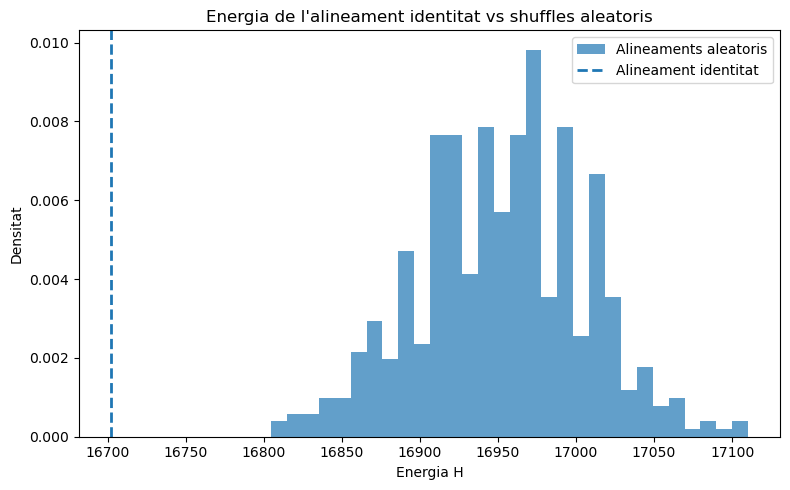

In [35]:
# Representem només una mostra per tenir una figura clara
sample_to_plot = 0

H_identity_plot = H_identity_list[sample_to_plot]
H_shuffle_plot = H_shuffle_by_sample[sample_to_plot]

plt.figure(figsize=(8, 5))

plt.hist(
    H_shuffle_plot,
    bins=30,
    density=True,
    alpha=0.7,
    label="Alineaments aleatoris"
)

plt.axvline(
    H_identity_plot,
    linestyle="--",
    linewidth=2,
    label="Alineament identitat"
)

plt.xlabel("Energia H")
plt.ylabel("Densitat")
plt.title("Energia de l'alineament identitat vs shuffles aleatoris")
plt.legend()
plt.tight_layout()
plt.show()

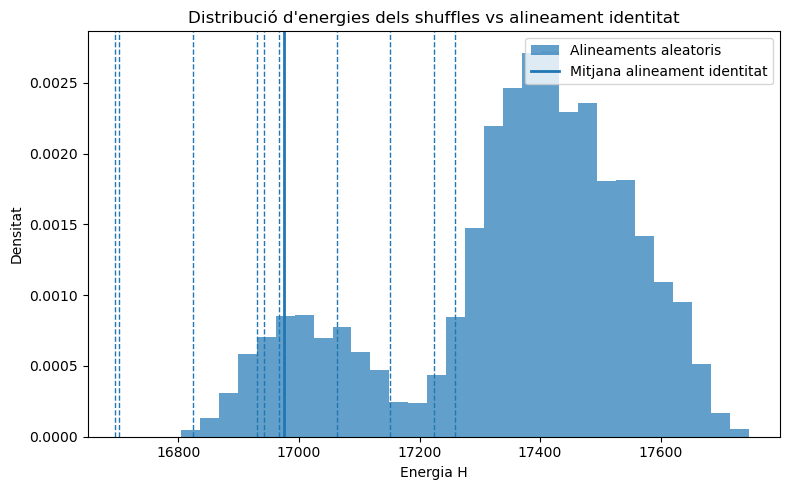

In [36]:
import matplotlib.pyplot as plt

H_identity_array = np.array(H_identity_list)
H_shuffle_array = np.array(H_shuffle_all)

plt.figure(figsize=(8, 5))

plt.hist(
    H_shuffle_array,
    bins=30,
    density=True,
    alpha=0.7,
    label="Alineaments aleatoris"
)

for H_id in H_identity_array:
    plt.axvline(H_id, linestyle="--", linewidth=1)

plt.axvline(
    H_identity_array.mean(),
    linewidth=2,
    label="Mitjana alineament identitat"
)

plt.xlabel("Energia H")
plt.ylabel("Densitat")
plt.title("Distribució d'energies dels shuffles vs alineament identitat")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
Path("results").mkdir(exist_ok=True)

np.save("results/H_identity_10_samples.npy", H_identity_array)
np.save("results/H_shuffle_10_samples.npy", H_shuffle_array)
energy_summary.to_csv("results/energy_sanity_check_summary.csv", index=False)

print("Resultats guardats a la carpeta results/")

Resultats guardats a la carpeta results/
